# 📡 Telco Customer Churn Prediction
## Comparative Machine Learning Analysis — End-to-End Data Science Project

---

**Dataset:** [Telco Customer Churn — Kaggle](https://www.kaggle.com/datasets/blastchar/telco-customer-churn)  
**Objective:** Build a predictive framework to classify whether a telecom subscriber will churn or remain active.  
**Models:** Logistic Regression · Decision Tree · Random Forest · KNN · SVM · XGBoost (+ Tuned variants)  
**Champion:** XGBoost (Tuned) — ROC-AUC: 0.838

---

## 📋 Table of Contents
1. [Phase 1 — Problem Understanding](#phase1)
2. [Phase 2 — Dataset Understanding](#phase2)
3. [Phase 3 — Exploratory Data Analysis](#phase3)
4. [Phase 4 — Data Preprocessing](#phase4)
5. [Phase 5 — Machine Learning Models](#phase5)
6. [Phase 6 — Model Comparison Analysis](#phase6)
7. [Phase 7 — Hyperparameter Tuning](#phase7)
8. [Summary & Conclusions](#summary)


---
<a id='phase1'></a>
## 🎯 Phase 1 — Problem Understanding

### Business Context
Customer churn refers to subscribers discontinuing their service contracts. For telecom companies:
- **Acquiring a new customer costs 5–7× more** than retaining an existing one
- Each churned customer removes recurring monthly revenue
- High churn rates signal service quality or pricing dissatisfaction

### Primary Objective
> Build a binary classification model to predict whether a customer will **Churn (Yes)** or remain **Active (No)**, enabling targeted retention strategies before the customer leaves.

### Success Criteria

| Metric | Business Rationale |
|---|---|
| **Recall** | Must capture as many true churners as possible — missing one = lost revenue |
| **Precision** | Minimize false alarms — wasted marketing spend on non-churners |
| **ROC-AUC** | Overall model discrimination ability across thresholds |
| **F1 Score** | Harmonic balance between Precision and Recall |


---
<a id='phase2'></a>
## 📊 Phase 2 — Dataset Understanding

### 2.1 — Import Libraries


In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import plotly.express as px
import plotly.graph_objects as go

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve,
    precision_recall_curve, classification_report
)
import joblib, os, json

plt.rcParams.update({
    'figure.facecolor': '#0f0f1a', 'axes.facecolor': '#1a1a2e',
    'axes.edgecolor': '#444466', 'axes.labelcolor': '#e0e0ff',
    'xtick.color': '#a0a0cc', 'ytick.color': '#a0a0cc',
    'text.color': '#e0e0ff', 'grid.color': '#2a2a4a',
    'grid.linewidth': 0.5, 'font.size': 11,
})
PALETTE = ['#7b2fff','#ff6b6b','#00d4ff','#ffd700','#00ff9f','#ff9f43','#ff69b4','#98fb98']
CHURN_COLORS = {'No': '#00d4ff', 'Yes': '#ff6b6b'}

print("All libraries imported successfully")

All libraries imported successfully


### 2.2 — Load Dataset

We load the Telco Customer Churn CSV file containing 7,043 subscriber records. Each row represents a unique customer account with 21 features spanning demographics, service subscriptions, billing details, and the binary churn target variable.


In [2]:
DATA_PATH = '../data/Telco-Customer-Churn.csv'
df = pd.read_csv(DATA_PATH)

print("=" * 50)
print("  DATASET DIMENSIONS")
print("=" * 50)
print(f"  Rows    : {df.shape[0]:,}")
print(f"  Columns : {df.shape[1]}")
print("=" * 50)
df.head()

  DATASET DIMENSIONS
  Rows    : 7,043
  Columns : 21


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### 2.3 — Data Types & Feature Profiling

Before any transformation, we must audit the raw data types of every column. A common pitfall in this dataset is `TotalCharges` being stored as an `object` (string) instead of `float64` — a hidden data quality issue that will cause model training failures if not caught early.


In [3]:
print("COLUMN DATA TYPES")
print("-" * 40)
print(df.dtypes)
print()

continuous_num = ['tenure', 'MonthlyCharges', 'TotalCharges']
discrete_num   = ['SeniorCitizen']
nominal_cat    = ['gender','Partner','Dependents','PhoneService','MultipleLines',
                  'InternetService','OnlineSecurity','OnlineBackup','DeviceProtection',
                  'TechSupport','StreamingTV','StreamingMovies','PaymentMethod']
ordinal_cat    = ['Contract']
target         = ['Churn']

print("FEATURE CLASSIFICATION")
print(f"  Continuous Numerical : {continuous_num}")
print(f"  Discrete Numerical   : {discrete_num}")
print(f"  Nominal Categorical  : {len(nominal_cat)} columns")
print(f"  Ordinal Categorical  : {ordinal_cat}")
print()
print(f"WARNING: TotalCharges dtype = '{df['TotalCharges'].dtype}' - must convert to float!")

COLUMN DATA TYPES
----------------------------------------
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

FEATURE CLASSIFICATION
  Continuous Numerical : ['tenure', 'MonthlyCharges', 'TotalCharges']
  Discrete Numerical   : ['SeniorCitizen']
  Nominal Categorical  : 13 columns
  Ordinal Categorical  : ['Contract']



### 2.4 — Data Integrity & Null Audit

We systematically quantify missing values, whitespace-encoded nulls, and duplicate rows. Telecom datasets frequently contain hidden nulls disguised as empty strings — particularly in billing columns where brand-new customers (tenure=0) have never been charged.


In [4]:
print("NULL VALUE AUDIT")
print("-" * 40)
nulls = df.isnull().sum()
print(nulls.to_string())
print(f"\nTotal null cells (surface): {nulls.sum()}")
print()

# Hidden nulls in TotalCharges
df_temp = df.copy()
df_temp['TotalCharges'] = pd.to_numeric(df_temp['TotalCharges'].replace(' ', np.nan), errors='coerce')
hidden = df_temp['TotalCharges'].isnull().sum()
print(f"Hidden whitespace nulls in TotalCharges: {hidden}")
print(f"All have tenure=0 (brand-new, never billed customers)")
print()
print(df_temp[df_temp['TotalCharges'].isnull()][['customerID','tenure','MonthlyCharges','TotalCharges']].head())
print()
print(f"Duplicate Rows: {df.duplicated().sum()}")

NULL VALUE AUDIT
----------------------------------------
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0

Total null cells (surface): 0

Hidden whitespace nulls in TotalCharges: 11
All have tenure=0 (brand-new, never billed customers)

      customerID  tenure  MonthlyCharges  TotalCharges
488   4472-LVYGI       0           52.55           NaN
753   3115-CZMZD       0           20.25           NaN
936   5709-LVOEQ       0           80.85           NaN
1082  4367-NUYAO       0           25.75           NaN
1340  1371-DWPAZ       0           56.05           NaN

Duplicate Rows: 0


### 2.5 — Target Class Balance

Understanding the churn class distribution is critical before model selection. A heavily imbalanced target (e.g., 95/5 split) would render accuracy meaningless and necessitate techniques like SMOTE or class weighting. We visualize both absolute counts and proportional distribution to assess the severity of any imbalance.


TARGET CLASS DISTRIBUTION
-----------------------------------
  No   : 5,174 (73.5%)
  Yes  : 1,869 (26.5%)

  Imbalance Ratio: 2.77:1 (No:Yes)
  Moderate imbalance — use ROC-AUC and F1, not raw Accuracy alone


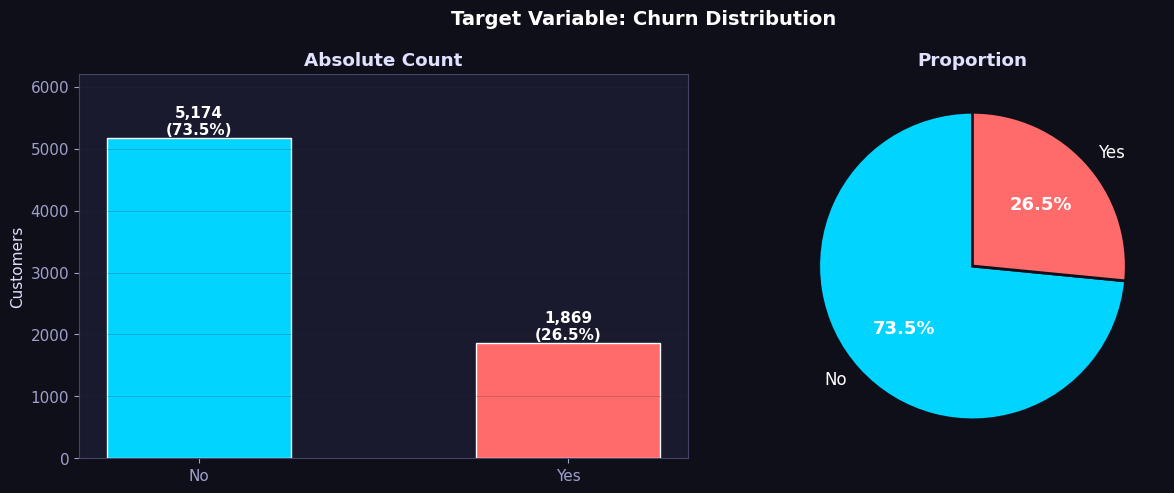

In [5]:
churn_counts = df['Churn'].value_counts()
churn_pct    = df['Churn'].value_counts(normalize=True) * 100

print("TARGET CLASS DISTRIBUTION")
print("-" * 35)
for label in churn_counts.index:
    print(f"  {label:5s}: {churn_counts[label]:,} ({churn_pct[label]:.1f}%)")
print()
print(f"  Imbalance Ratio: {churn_counts['No']/churn_counts['Yes']:.2f}:1 (No:Yes)")
print("  Moderate imbalance — use ROC-AUC and F1, not raw Accuracy alone")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor('#0f0f1a')
fig.suptitle('Target Variable: Churn Distribution', fontsize=14, fontweight='bold', color='white')

colors = [CHURN_COLORS['No'], CHURN_COLORS['Yes']]
bars = axes[0].bar(churn_counts.index, churn_counts.values, color=colors, edgecolor='white', width=0.5)
for bar, val in zip(bars, churn_counts.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+50,
                 f'{val:,}\n({val/len(df)*100:.1f}%)', ha='center', fontsize=11, fontweight='bold', color='white')
axes[0].set_ylim(0, churn_counts.max()*1.2)
axes[0].set_title('Absolute Count', fontweight='bold'); axes[0].set_ylabel('Customers'); axes[0].grid(axis='y', alpha=0.3)

wedges, texts, autotexts = axes[1].pie(churn_counts.values, labels=churn_counts.index, colors=colors,
    autopct='%1.1f%%', startangle=90, textprops={'color':'white','fontsize':12},
    wedgeprops={'edgecolor':'#0f0f1a','linewidth':2})
for at in autotexts: at.set_fontsize(13); at.set_fontweight('bold')
axes[1].set_title('Proportion', fontweight='bold')

plt.tight_layout()
plt.savefig('../visuals/01_churn_distribution.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()

---
<a id='phase3'></a>
## 🔍 Phase 3 — Exploratory Data Analysis (EDA)

### 3.1 — Univariate Analysis: Numerical Features


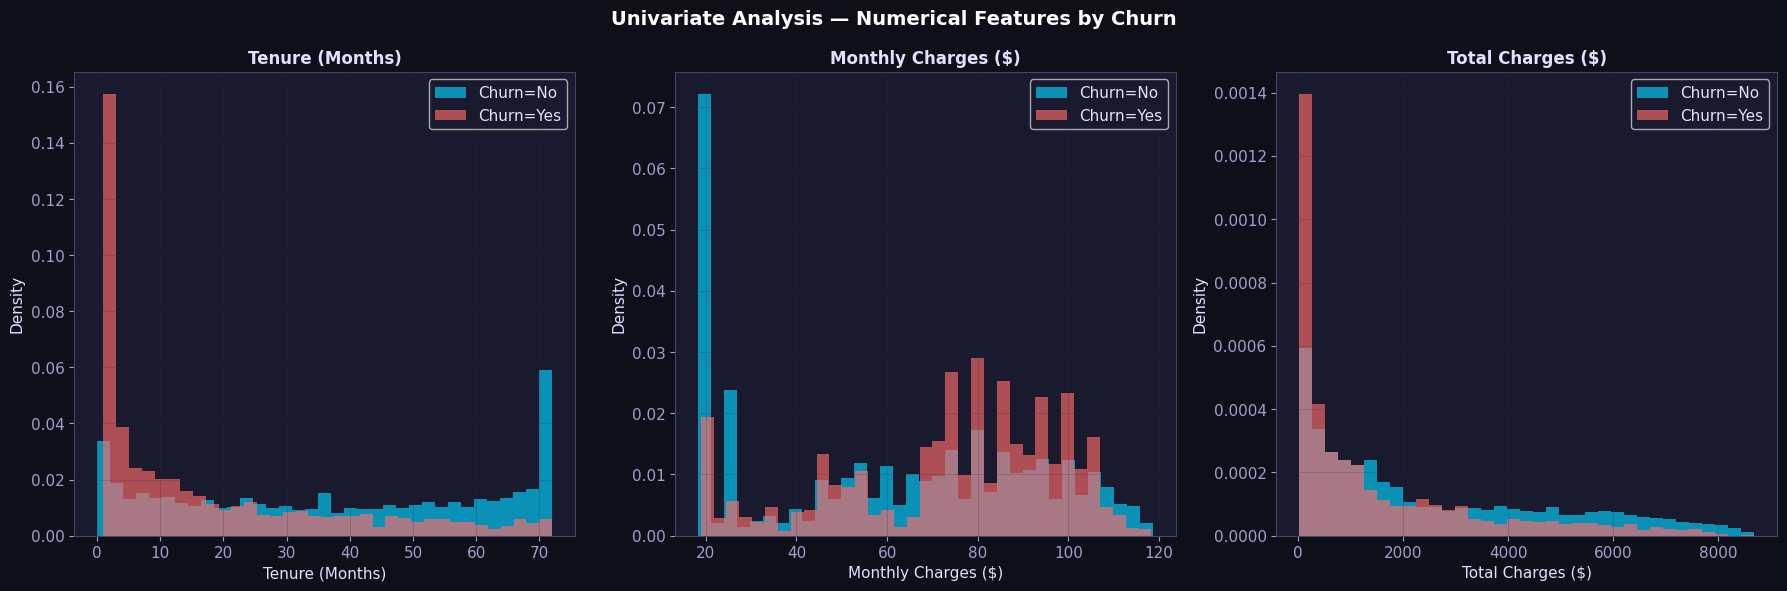


KEY INSIGHTS — Univariate:
  Tenure        : Churners concentrated at low tenure (<12 months). Long-term customers rarely churn.
  MonthlyCharges: Churners tend to pay MORE ($65-$100 range vs retained customers).
  TotalCharges  : Lower total for churners because they leave early — not a cause, a consequence.



In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.patch.set_facecolor('#0f0f1a')
fig.suptitle('Univariate Analysis — Numerical Features by Churn', fontsize=14, fontweight='bold', color='white')

for ax, (col, label) in zip(axes, [('tenure','Tenure (Months)'),('MonthlyCharges','Monthly Charges ($)'),('TotalCharges','Total Charges ($)')]):
    for churn_val, c in [('No','#00d4ff'),('Yes','#ff6b6b')]:
        subset = df[df['Churn']==churn_val][col]
        if col=='TotalCharges': subset = pd.to_numeric(subset.replace(' ',np.nan),errors='coerce').dropna()
        ax.hist(subset, bins=35, alpha=0.65, color=c, edgecolor='none', label=f'Churn={churn_val}', density=True)
    ax.set_title(label, fontsize=12, fontweight='bold'); ax.set_xlabel(label); ax.set_ylabel('Density')
    ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../visuals/02_univariate_numerical.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()

print("""
KEY INSIGHTS — Univariate:
  Tenure        : Churners concentrated at low tenure (<12 months). Long-term customers rarely churn.
  MonthlyCharges: Churners tend to pay MORE ($65-$100 range vs retained customers).
  TotalCharges  : Lower total for churners because they leave early — not a cause, a consequence.
""")

### 3.2 — Univariate Analysis: Senior Citizen & Demographics

Demographic segmentation reveals which customer groups face disproportionate churn risk. Senior citizens, while representing a smaller segment, may exhibit significantly different churn behavior due to varying technology adoption patterns, pricing sensitivity, or service needs. We also examine gender and partner status as potential risk modifiers.


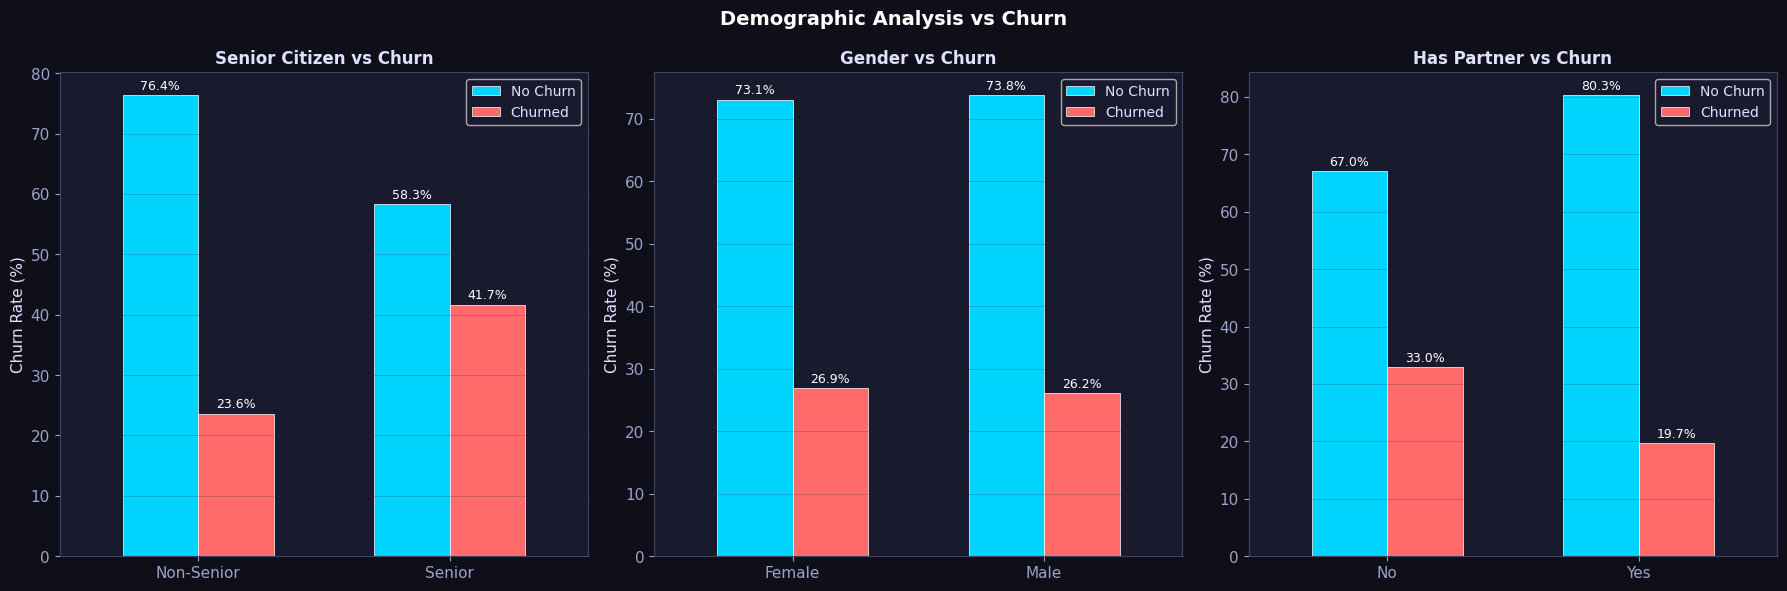


KEY INSIGHTS — Demographics:
  Senior Citizens : 41.7% churn vs 23.6% Non-Senior — nearly 2x higher risk
  Gender          : Minimal difference (Male 26.2% vs Female 26.9%)
  Partner         : No partner = 33% churn vs 20% with partner



In [7]:
df_sc = df.copy()
df_sc['SeniorCitizen'] = df_sc['SeniorCitizen'].map({0:'Non-Senior',1:'Senior'})

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.patch.set_facecolor('#0f0f1a')
fig.suptitle('Demographic Analysis vs Churn', fontsize=14, fontweight='bold', color='white')

for ax, (col, label) in zip(axes, [('SeniorCitizen','Senior Citizen'),('gender','Gender'),('Partner','Has Partner')]):
    ct = pd.crosstab(df_sc[col], df_sc['Churn'], normalize='index') * 100
    ct.plot(kind='bar', ax=ax, color=[CHURN_COLORS['No'],CHURN_COLORS['Yes']], edgecolor='white', linewidth=0.5, width=0.6)
    ax.set_title(f'{label} vs Churn', fontsize=12, fontweight='bold')
    ax.set_xlabel(''); ax.set_ylabel('Churn Rate (%)')
    ax.legend(['No Churn','Churned'], fontsize=10); ax.set_xticklabels(ax.get_xticklabels(), rotation=0); ax.grid(axis='y', alpha=0.3)
    for container in ax.containers: ax.bar_label(container, fmt='%.1f%%', fontsize=9, color='white', padding=2)

plt.tight_layout()
plt.savefig('../visuals/03_demographics_churn.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()

print("""
KEY INSIGHTS — Demographics:
  Senior Citizens : 41.7% churn vs 23.6% Non-Senior — nearly 2x higher risk
  Gender          : Minimal difference (Male 26.2% vs Female 26.9%)
  Partner         : No partner = 33% churn vs 20% with partner
""")

### 3.2b — Dependents & Family Structure vs Churn

Customers with dependents (children or elderly family members on the account) tend to exhibit higher account stickiness. Household obligations create switching barriers — a family plan is harder to abandon than an individual subscription. We visualize the churn rate differential between customers with and without dependents.


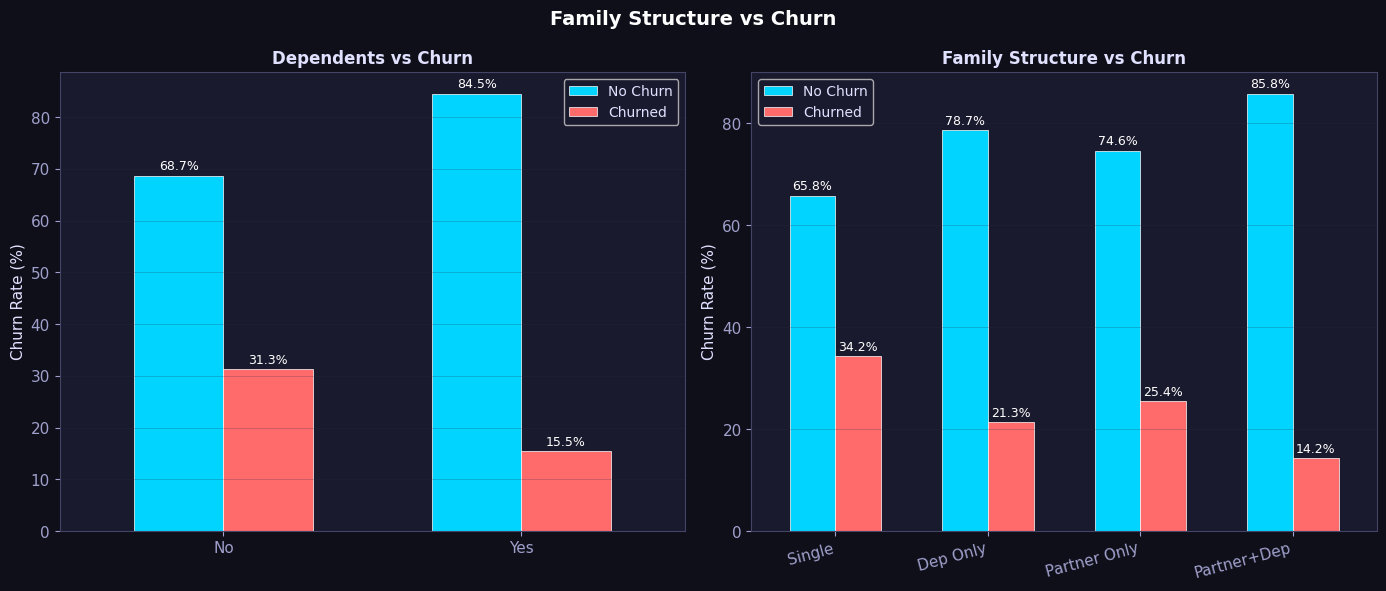


KEY INSIGHTS — Family Structure:
  Dependents=No  : ~31% churn vs Dependents=Yes : ~15% churn — nearly 2x risk
  Single (no partner, no dep): Highest churn risk segment
  Partner+Dependents: Lowest churn — family ties = switching barriers



In [8]:
# Dependents vs Churn Analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor('#0f0f1a')
fig.suptitle('Family Structure vs Churn', fontsize=14, fontweight='bold', color='white')

# Dependents vs Churn
ct_dep = pd.crosstab(df['Dependents'], df['Churn'], normalize='index') * 100
ct_dep.plot(kind='bar', ax=axes[0], color=[CHURN_COLORS['No'], CHURN_COLORS['Yes']],
            edgecolor='white', linewidth=0.5, width=0.6)
axes[0].set_title('Dependents vs Churn', fontsize=12, fontweight='bold')
axes[0].set_xlabel(''); axes[0].set_ylabel('Churn Rate (%)')
axes[0].legend(['No Churn', 'Churned'], fontsize=10)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
axes[0].grid(axis='y', alpha=0.3)
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.1f%%', fontsize=9, color='white', padding=2)

# Combined: Partner + Dependents interaction
df_fam = df.copy()
df_fam['Family'] = df_fam.apply(lambda r: 'Partner+Dep' if r['Partner']=='Yes' and r['Dependents']=='Yes'
    else 'Partner Only' if r['Partner']=='Yes' else 'Dep Only' if r['Dependents']=='Yes'
    else 'Single', axis=1)
ct_fam = pd.crosstab(df_fam['Family'], df_fam['Churn'], normalize='index') * 100
order = ['Single', 'Dep Only', 'Partner Only', 'Partner+Dep']
ct_fam = ct_fam.reindex(order)
ct_fam.plot(kind='bar', ax=axes[1], color=[CHURN_COLORS['No'], CHURN_COLORS['Yes']],
            edgecolor='white', linewidth=0.5, width=0.6)
axes[1].set_title('Family Structure vs Churn', fontsize=12, fontweight='bold')
axes[1].set_xlabel(''); axes[1].set_ylabel('Churn Rate (%)')
axes[1].legend(['No Churn', 'Churned'], fontsize=10)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=15, ha='right')
axes[1].grid(axis='y', alpha=0.3)
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.1f%%', fontsize=9, color='white', padding=2)

plt.tight_layout()
plt.show()

print("""
KEY INSIGHTS — Family Structure:
  Dependents=No  : ~31% churn vs Dependents=Yes : ~15% churn — nearly 2x risk
  Single (no partner, no dep): Highest churn risk segment
  Partner+Dependents: Lowest churn — family ties = switching barriers
""")


### 3.2c — Box & Violin Plots: Numerical Feature Distributions

Beyond histograms, box plots reveal outliers and quartile spreads, while violin plots show the full probability density shape. These complementary views help identify whether churners cluster at specific charge levels or tenure ranges — information that histograms can obscure through binning.


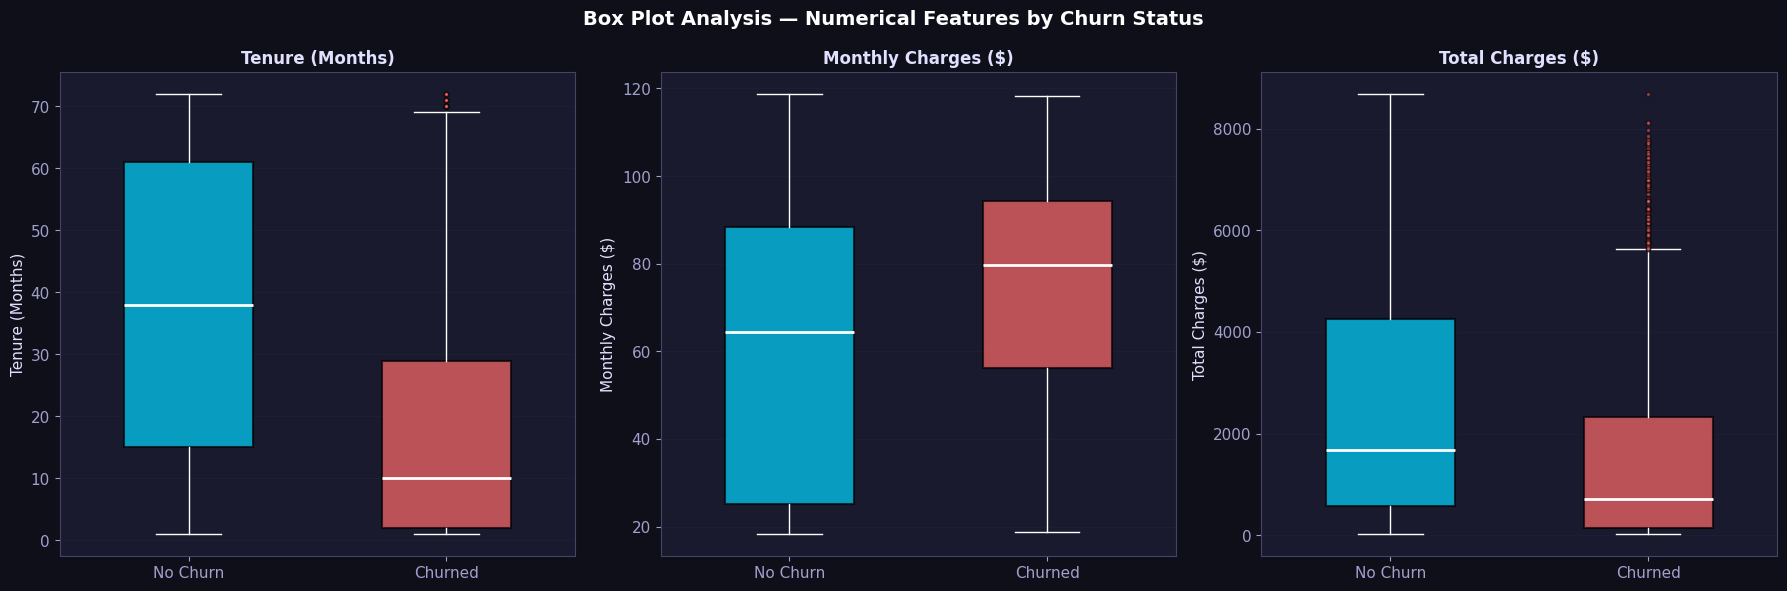

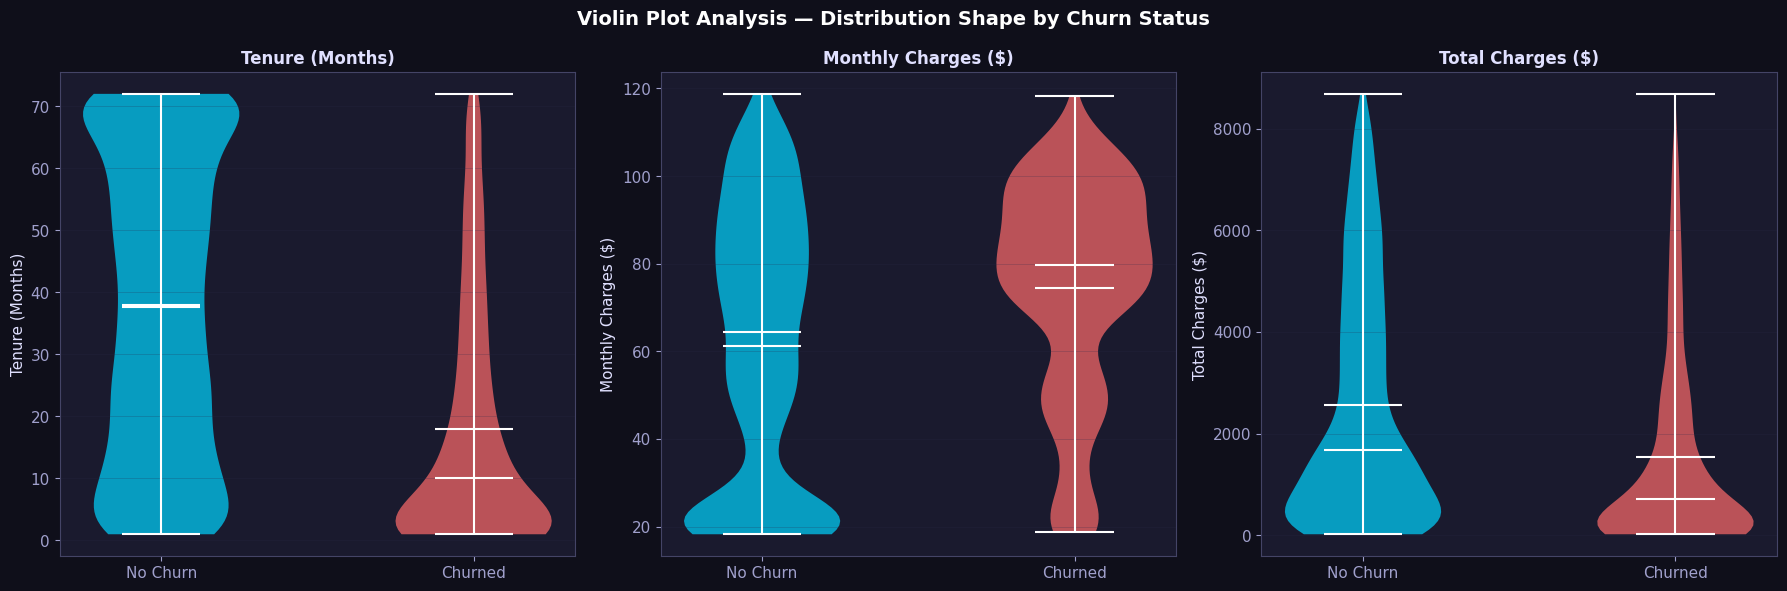


KEY INSIGHTS — Box & Violin Plots:
  Tenure      : Churners have median ~10 months vs ~38 months for retained — clear separation
  Monthly     : Churner median ($80) is higher than retained ($65) — premium plans churn more
  Total       : Churners have lower totals (leave early), retained show wide spread up to $8000+



In [9]:
# Box Plots: Numerical features split by Churn
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.patch.set_facecolor('#0f0f1a')
fig.suptitle('Box Plot Analysis — Numerical Features by Churn Status', fontsize=14, fontweight='bold', color='white')

df_box = df.copy()
df_box['TotalCharges'] = pd.to_numeric(df_box['TotalCharges'].replace(' ', np.nan), errors='coerce')
df_box.dropna(subset=['TotalCharges'], inplace=True)

for ax, (col, label) in zip(axes, [('tenure','Tenure (Months)'),
                                    ('MonthlyCharges','Monthly Charges ($)'),
                                    ('TotalCharges','Total Charges ($)')]):
    bp = ax.boxplot([df_box[df_box['Churn']=='No'][col].values,
                     df_box[df_box['Churn']=='Yes'][col].values],
                    labels=['No Churn', 'Churned'],
                    patch_artist=True, widths=0.5,
                    boxprops=dict(linewidth=1.5),
                    medianprops=dict(color='white', linewidth=2),
                    whiskerprops=dict(color='white'),
                    capprops=dict(color='white'),
                    flierprops=dict(marker='o', markerfacecolor='#ff6b6b', markersize=3, alpha=0.5))
    bp['boxes'][0].set_facecolor('#00d4ff')
    bp['boxes'][0].set_alpha(0.7)
    bp['boxes'][1].set_facecolor('#ff6b6b')
    bp['boxes'][1].set_alpha(0.7)
    ax.set_title(label, fontsize=12, fontweight='bold')
    ax.set_ylabel(label)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Violin Plots
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.patch.set_facecolor('#0f0f1a')
fig.suptitle('Violin Plot Analysis — Distribution Shape by Churn Status', fontsize=14, fontweight='bold', color='white')

for ax, (col, label) in zip(axes, [('tenure','Tenure (Months)'),
                                    ('MonthlyCharges','Monthly Charges ($)'),
                                    ('TotalCharges','Total Charges ($)')]):
    data_no = df_box[df_box['Churn']=='No'][col].values
    data_yes = df_box[df_box['Churn']=='Yes'][col].values
    vp = ax.violinplot([data_no, data_yes], positions=[1, 2], showmeans=True, showmedians=True)
    vp['bodies'][0].set_facecolor('#00d4ff')
    vp['bodies'][0].set_alpha(0.7)
    vp['bodies'][1].set_facecolor('#ff6b6b')
    vp['bodies'][1].set_alpha(0.7)
    for pc in ['cmeans', 'cmedians', 'cmins', 'cmaxes', 'cbars']:
        if pc in vp: vp[pc].set_color('white')
    ax.set_xticks([1, 2])
    ax.set_xticklabels(['No Churn', 'Churned'])
    ax.set_title(label, fontsize=12, fontweight='bold')
    ax.set_ylabel(label)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("""
KEY INSIGHTS — Box & Violin Plots:
  Tenure      : Churners have median ~10 months vs ~38 months for retained — clear separation
  Monthly     : Churner median ($80) is higher than retained ($65) — premium plans churn more
  Total       : Churners have lower totals (leave early), retained show wide spread up to $8000+
""")


### 3.3 — Bivariate Analysis: Contract, Payment & Internet vs Churn

This is the most business-critical EDA section. Contract type, payment method, and internet service are the three strongest predictive signals in telecom churn. Month-to-month flexibility removes switching barriers, electronic check users show disengagement patterns, and Fiber Optic — despite being a premium service — often correlates with higher churn due to pricing or unmet expectations.


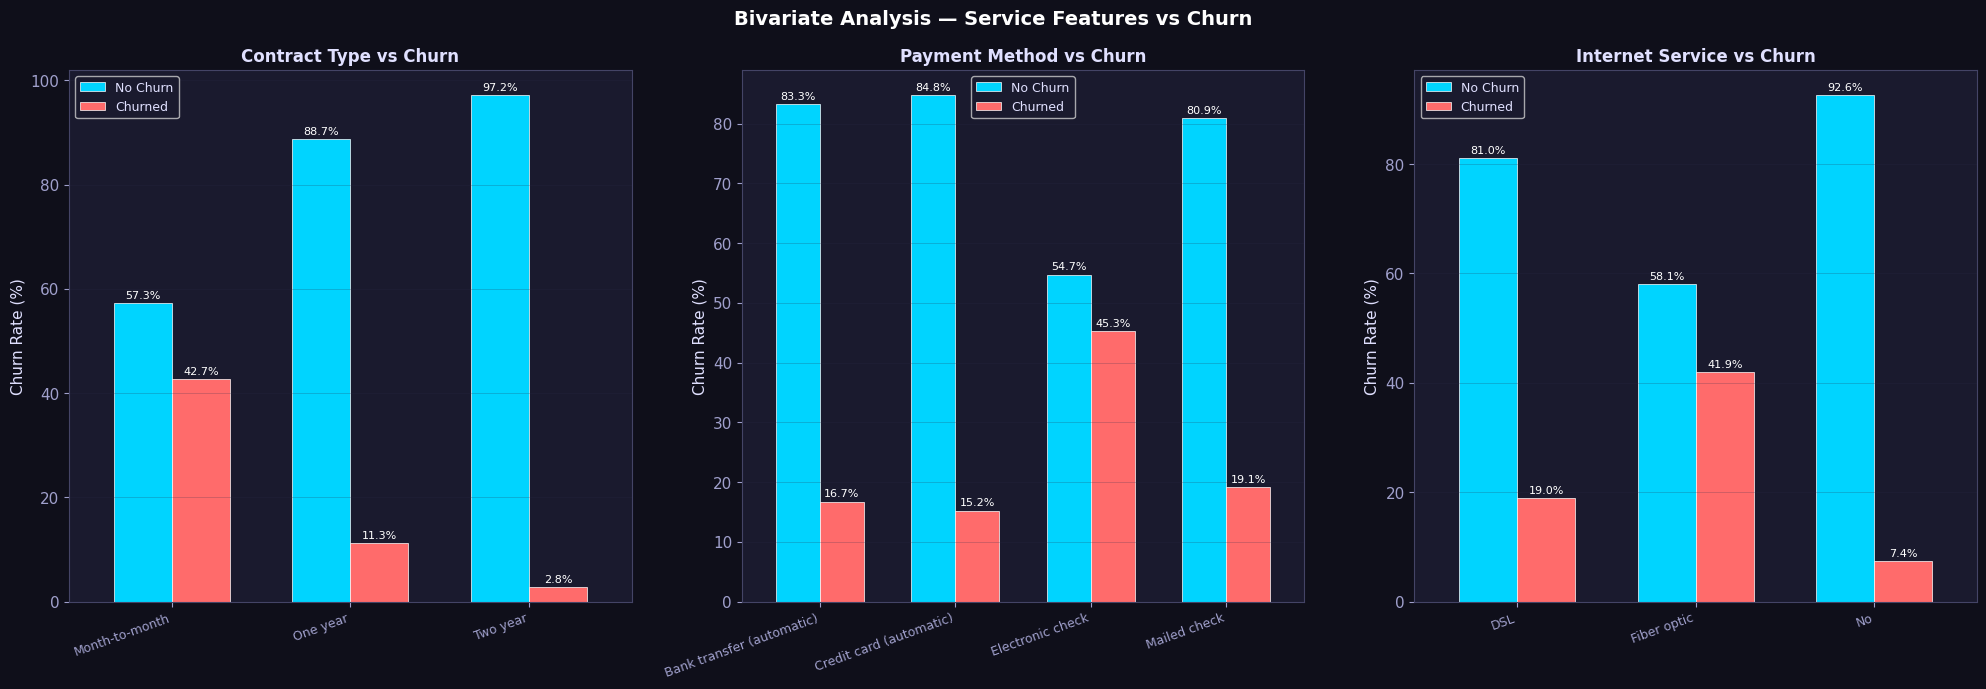


KEY INSIGHTS — Bivariate:
  CONTRACT    : Month-to-month = 42.7% churn | One-year = 11.3% | Two-year = 2.8%
  PAYMENT     : Electronic check = 45.3% | Auto-pay methods ~15-16%
  INTERNET    : Fiber Optic = 41.9% | DSL = 19.0% | No internet = 7.4%



In [10]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.patch.set_facecolor('#0f0f1a')
fig.suptitle('Bivariate Analysis — Service Features vs Churn', fontsize=14, fontweight='bold', color='white')

for ax, (col, label) in zip(axes, [('Contract','Contract Type'),('PaymentMethod','Payment Method'),('InternetService','Internet Service')]):
    ct = pd.crosstab(df[col], df['Churn'], normalize='index') * 100
    ct.plot(kind='bar', ax=ax, color=[CHURN_COLORS['No'],CHURN_COLORS['Yes']], edgecolor='white', linewidth=0.5, width=0.65)
    ax.set_title(f'{label} vs Churn', fontsize=12, fontweight='bold')
    ax.set_xlabel(''); ax.set_ylabel('Churn Rate (%)')
    ax.legend(['No Churn','Churned'], fontsize=9); ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right', fontsize=9)
    ax.grid(axis='y', alpha=0.3)
    for container in ax.containers: ax.bar_label(container, fmt='%.1f%%', fontsize=8, color='white', padding=2)

plt.tight_layout()
plt.savefig('../visuals/04_bivariate_service_churn.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()

print("""
KEY INSIGHTS — Bivariate:
  CONTRACT    : Month-to-month = 42.7% churn | One-year = 11.3% | Two-year = 2.8%
  PAYMENT     : Electronic check = 45.3% | Auto-pay methods ~15-16%
  INTERNET    : Fiber Optic = 41.9% | DSL = 19.0% | No internet = 7.4%
""")

### 3.4 — Correlation Heatmap

We construct a full feature correlation matrix to identify multicollinearity between predictors and measure linear relationships with the churn target. A triangular heatmap with annotated coefficients helps spot redundant features (e.g., tenure ↔ TotalCharges) and confirms which variables have the strongest statistical association with customer attrition.

> **Note:** Categorical variables are encoded via binary mapping and factorization for correlation computation. This introduces ordinal assumptions for nominal features — results should be interpreted as directional indicators rather than exact linear relationships.


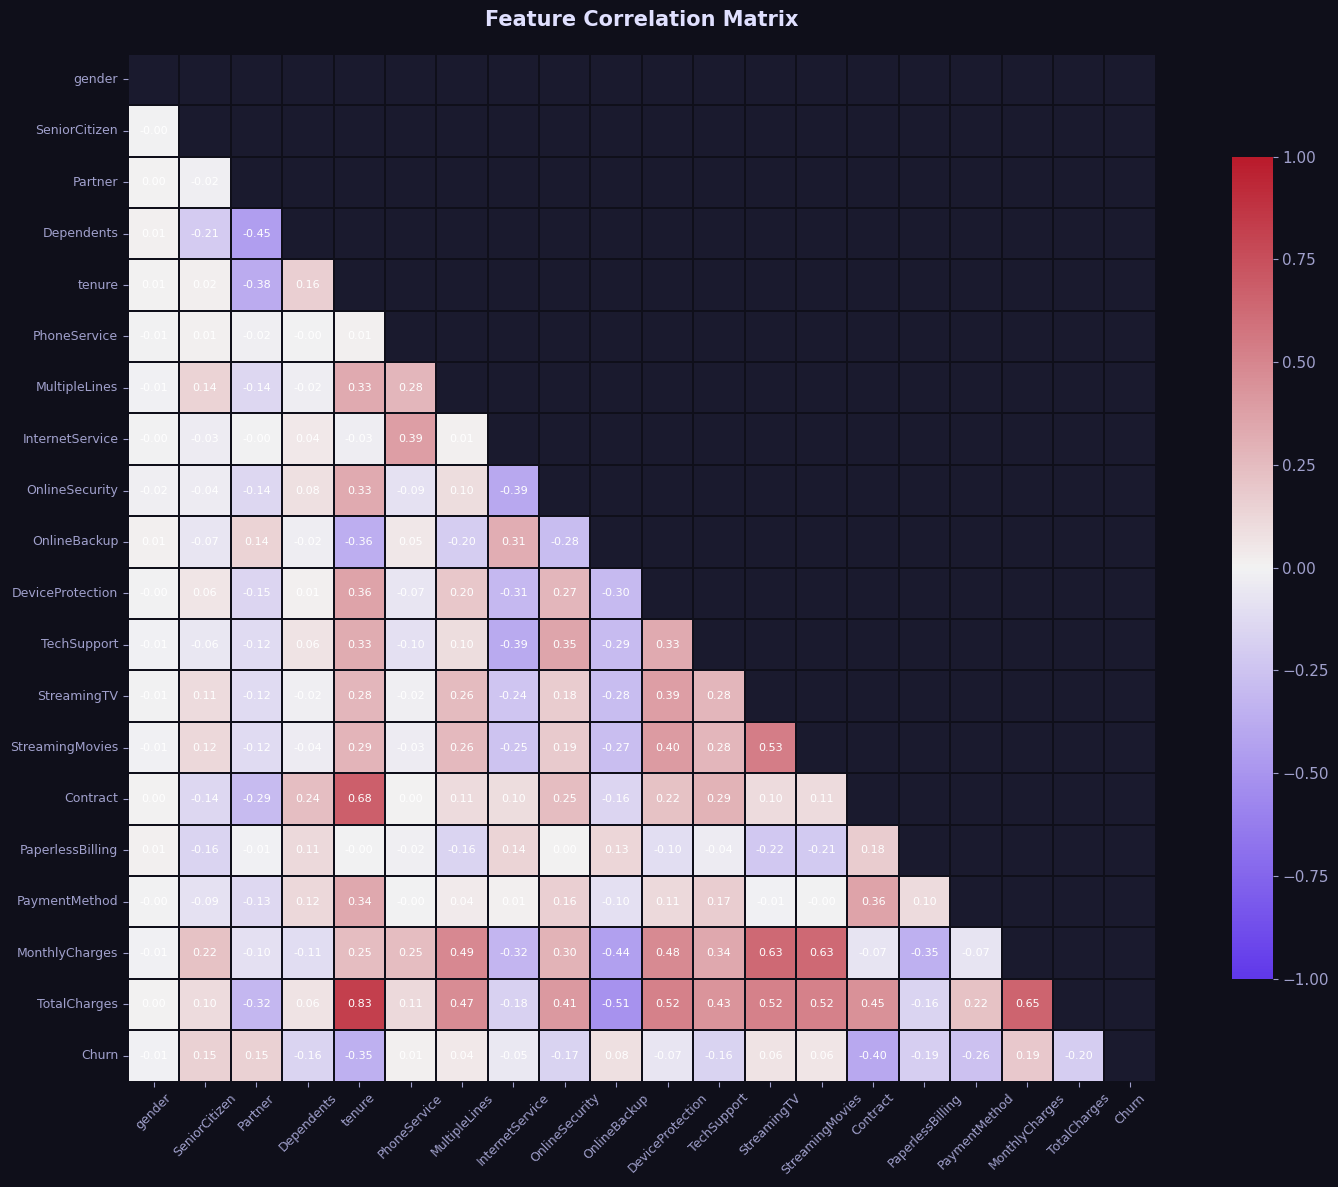

TOP CORRELATIONS WITH CHURN:
  Contract               -0.396
  tenure                 -0.354
  PaymentMethod          -0.263
  TotalCharges           -0.199
  MonthlyCharges         +0.193
  PaperlessBilling       -0.191
  OnlineSecurity         -0.171
  TechSupport            -0.165
  Dependents             -0.163
  SeniorCitizen          +0.151


In [11]:
df_enc = df.copy()
df_enc['TotalCharges'] = pd.to_numeric(df_enc['TotalCharges'].replace(' ',np.nan), errors='coerce')
df_enc.dropna(subset=['TotalCharges'], inplace=True)
bmap = {'Yes':1,'No':0,'Male':1,'Female':0,'No phone service':0,'No internet service':0}
for col in df_enc.select_dtypes('object').columns:
    if col not in ['customerID']:
        df_enc[col] = df_enc[col].map(lambda x: bmap.get(x,x))
        df_enc[col] = pd.factorize(df_enc[col])[0]
df_enc.drop(columns=['customerID'], inplace=True)
corr = df_enc.corr()

fig, ax = plt.subplots(figsize=(16, 12))
fig.patch.set_facecolor('#0f0f1a')
mask = np.triu(np.ones_like(corr, dtype=bool))
cmap = sns.diverging_palette(270, 10, s=90, l=40, as_cmap=True)
sns.heatmap(corr, mask=mask, cmap=cmap, center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.3, linecolor='#0f0f1a',
    annot=True, fmt='.2f', annot_kws={'size':8,'color':'white'},
    ax=ax, cbar_kws={'shrink':0.8})
ax.set_title('Feature Correlation Matrix', fontsize=15, fontweight='bold', pad=20)
ax.tick_params(axis='x', rotation=45, labelsize=9); ax.tick_params(axis='y', rotation=0, labelsize=9)
plt.tight_layout()
plt.savefig('../visuals/05_correlation_heatmap.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()

print("TOP CORRELATIONS WITH CHURN:")
churn_corr = corr['Churn'].drop('Churn').sort_values(key=abs, ascending=False).head(10)
for feat, val in churn_corr.items():
    print(f"  {feat:<22} {val:+.3f}")

### 3.5 — Mutual Information Feature Importance

Unlike Pearson correlation (which only captures linear relationships), Mutual Information measures the general statistical dependency between each feature and the churn target — including non-linear associations. This provides a complementary, model-agnostic view of feature relevance before we begin training classifiers.


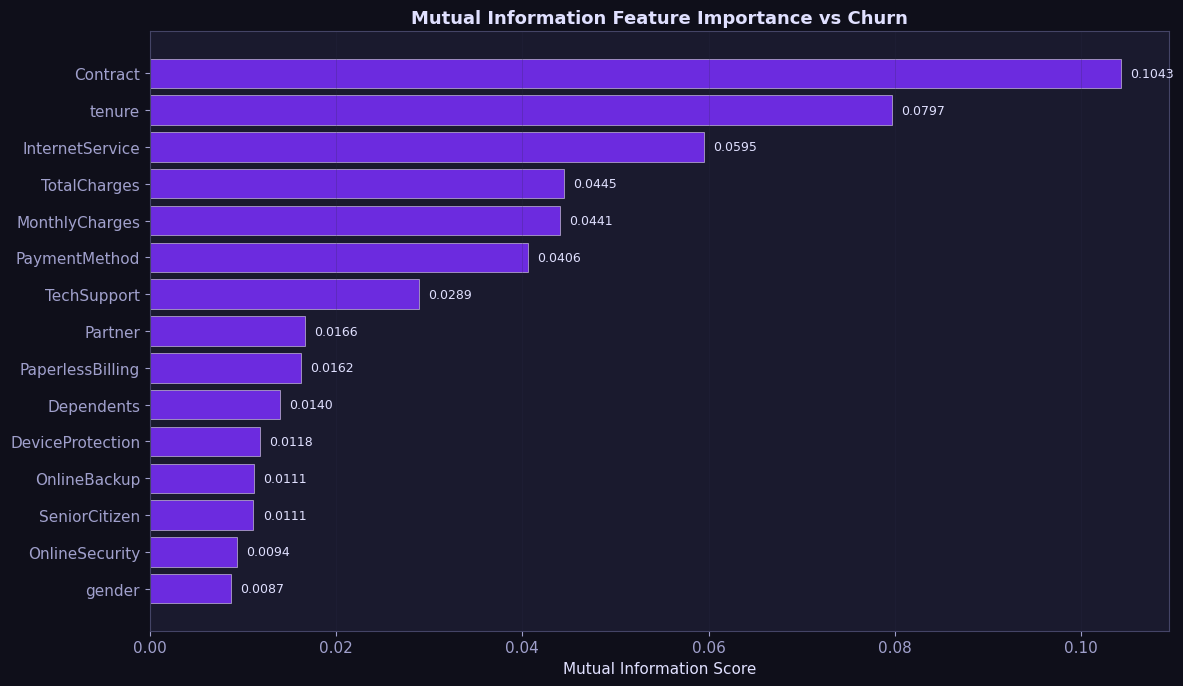

TOP 5 FEATURES BY MUTUAL INFORMATION:
  Contract               MI = 0.1043
  tenure                 MI = 0.0797
  InternetService        MI = 0.0595
  TotalCharges           MI = 0.0445
  MonthlyCharges         MI = 0.0441


In [12]:
X_mi = df_enc.drop('Churn', axis=1)
y_mi = df_enc['Churn']
mi_scores = mutual_info_classif(X_mi, y_mi, random_state=42)
mi_df = pd.DataFrame({'Feature': X_mi.columns, 'MI Score': mi_scores})
mi_df = mi_df.sort_values('MI Score', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor('#0f0f1a')
bars = ax.barh(mi_df['Feature'][::-1], mi_df['MI Score'][::-1], color='#7b2fff', alpha=0.85, edgecolor='white', linewidth=0.4)
for bar, val in zip(bars, mi_df['MI Score'][::-1]):
    ax.text(val+0.001, bar.get_y()+bar.get_height()/2, f'{val:.4f}', va='center', fontsize=9)
ax.set_title('Mutual Information Feature Importance vs Churn', fontsize=13, fontweight='bold')
ax.set_xlabel('Mutual Information Score'); ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("TOP 5 FEATURES BY MUTUAL INFORMATION:")
for _, row in mi_df.head(5).iterrows():
    print(f"  {row['Feature']:<22} MI = {row['MI Score']:.4f}")

---
<a id='phase4'></a>
## ⚙️ Phase 4 — Data Preprocessing

### 4.1 — Handle Missing Values


In [13]:
df_clean = df.copy()
df_clean['TotalCharges'] = pd.to_numeric(df_clean['TotalCharges'].replace(' ',np.nan), errors='coerce')
before = len(df_clean)
df_clean.dropna(subset=['TotalCharges'], inplace=True)
after  = len(df_clean)

print(f"Rows before : {before:,}")
print(f"Rows removed: {before-after} (TotalCharges null, tenure=0)")
print(f"Rows after  : {after:,}")
print()
print("Decision: DROP these 11 rows.")
print("Rationale: tenure=0 = never billed. Imputing would introduce noise.")
print("<0.2% of data — negligible impact on model training.")

Rows before : 7,043
Rows removed: 11 (TotalCharges null, tenure=0)
Rows after  : 7,032

Decision: DROP these 11 rows.
Rationale: tenure=0 = never billed. Imputing would introduce noise.
<0.2% of data — negligible impact on model training.


### 4.2 — Encode Target & Binary Features

We apply binary mapping (Yes=1, No=0) to the target variable and all binary service columns. Multi-class nominal features (InternetService, Contract, PaymentMethod) receive One-Hot Encoding to avoid imposing artificial ordinal relationships. This preserves the categorical nature of the data while making it algorithm-compatible.


In [14]:
df_clean['Churn'] = (df_clean['Churn'] == 'Yes').astype(int)
print(f"Churn encoded: 'Yes'=1, 'No'=0 | Distribution: {df_clean['Churn'].value_counts().to_dict()}")
print()

binary_cols = ['Partner','Dependents','PhoneService','PaperlessBilling',
               'MultipleLines','OnlineSecurity','OnlineBackup',
               'DeviceProtection','TechSupport','StreamingTV','StreamingMovies']
for col in binary_cols:
    df_clean[col] = df_clean[col].map({'Yes':1,'No':0,'No phone service':0,'No internet service':0})
df_clean['gender'] = df_clean['gender'].map({'Male':1,'Female':0})
print(f"Binary Label Encoding applied to {len(binary_cols)+1} columns")

df_clean = pd.get_dummies(df_clean, columns=['InternetService','Contract','PaymentMethod'], drop_first=False)
print(f"One-Hot Encoding applied to: InternetService, Contract, PaymentMethod")
print(f"Total columns after encoding: {df_clean.shape[1]}")
df_clean.drop(columns=['customerID'], inplace=True, errors='ignore')

Churn encoded: 'Yes'=1, 'No'=0 | Distribution: {0: 5163, 1: 1869}

Binary Label Encoding applied to 12 columns
One-Hot Encoding applied to: InternetService, Contract, PaymentMethod
Total columns after encoding: 28


### 4.3 — Feature Scaling & Train-Test Split

StandardScaler normalizes continuous features (tenure, MonthlyCharges, TotalCharges) to zero mean and unit variance — essential for distance-based models like KNN and SVM. We use stratified 80/20 splitting to maintain identical churn proportions in both training and test sets, preventing evaluation bias from uneven class distributions.


In [15]:
X = df_clean.drop('Churn', axis=1)
y = df_clean['Churn']

# SPLIT FIRST — then scale to prevent data leakage
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train : {X_train.shape} | Churn rate: {y_train.mean():.3f}")
print(f"Test  : {X_test.shape}  | Churn rate: {y_test.mean():.3f}")
print("Stratified split — class proportions preserved")
print()

# Fit scaler on TRAIN only, transform both
scaler = StandardScaler()
scale_cols = ['tenure','MonthlyCharges','TotalCharges']
X_train[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_test[scale_cols]  = scaler.transform(X_test[scale_cols])

print(f"StandardScaler applied to: {scale_cols}")
print("Scaler fit on TRAINING data ONLY — no data leakage")

os.makedirs('../models', exist_ok=True)
joblib.dump(scaler, '../models/scaler.pkl')
joblib.dump(list(X.columns), '../models/feature_columns.pkl')
print("Scaler + feature columns saved to ../models/")

Train : (5625, 26) | Churn rate: 0.266
Test  : (1407, 26)  | Churn rate: 0.266
Stratified split — class proportions preserved

StandardScaler applied to: ['tenure', 'MonthlyCharges', 'TotalCharges']
Scaler fit on TRAINING data ONLY — no data leakage
Scaler + feature columns saved to ../models/


---
<a id='phase5'></a>
## 🤖 Phase 5 — Machine Learning Models

### 5.1 — Define & Train All 6 Models


In [16]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree':       DecisionTreeClassifier(random_state=42, max_depth=8),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'KNN':                 KNeighborsClassifier(n_neighbors=7),
    'SVM':                 SVC(probability=True, random_state=42, kernel='rbf'),
    'XGBoost':             XGBClassifier(n_estimators=100, random_state=42,
                                          use_label_encoder=False, eval_metric='logloss', verbosity=0),
}

results = {}
trained_models = {}

print(f"{'='*68}")
print(f"{'Model':<22} {'Acc':>6} {'Prec':>7} {'Rec':>7} {'F1':>7} {'AUC':>7}")
print(f"{'='*68}")

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]
    results[name] = {
        'Accuracy':  accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall':    recall_score(y_test, y_pred),
        'F1':        f1_score(y_test, y_pred),
        'ROC-AUC':   roc_auc_score(y_test, y_prob),
        'y_pred': y_pred, 'y_prob': y_prob,
    }
    trained_models[name] = model
    print(f"{name:<22} {results[name]['Accuracy']:>6.3f} {results[name]['Precision']:>7.3f} "
          f"{results[name]['Recall']:>7.3f} {results[name]['F1']:>7.3f} {results[name]['ROC-AUC']:>7.3f}")

print(f"{'='*68}")
print("All 6 models trained and evaluated.")

Model                     Acc    Prec     Rec      F1     AUC
Logistic Regression     0.804   0.649   0.570   0.607   0.836


Decision Tree           0.757   0.543   0.545   0.544   0.784


Random Forest           0.792   0.636   0.505   0.563   0.821


KNN                     0.762   0.551   0.561   0.556   0.796


SVM                     0.796   0.651   0.503   0.567   0.787


XGBoost                 0.775   0.585   0.527   0.554   0.812
All 6 models trained and evaluated.


### 5.2 — Classification Reports

We generate per-class precision, recall, and F1 scores for each model using `classification_report`. This provides granular insight into how well each algorithm handles the minority class (churned customers) — which is far more important than overall accuracy in an imbalanced business context.


In [17]:
for name in results:
    print(f"\n{'─'*55}")
    print(f"  {name}")
    print(f"{'─'*55}")
    print(classification_report(y_test, results[name]['y_pred'], target_names=['No Churn','Churned']))


───────────────────────────────────────────────────────
  Logistic Regression
───────────────────────────────────────────────────────
              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1033
     Churned       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407


───────────────────────────────────────────────────────
  Decision Tree
───────────────────────────────────────────────────────
              precision    recall  f1-score   support

    No Churn       0.84      0.83      0.83      1033
     Churned       0.54      0.55      0.54       374

    accuracy                           0.76      1407
   macro avg       0.69      0.69      0.69      1407
weighted avg       0.76      0.76      0.76      1407


───────────────────────────────────────────────────────
  Random Forest
─────────

---
<a id='phase6'></a>
## 📊 Phase 6 — Model Comparison Analysis

### 6.1 — Accuracy vs F1 & All Metrics Bar Charts


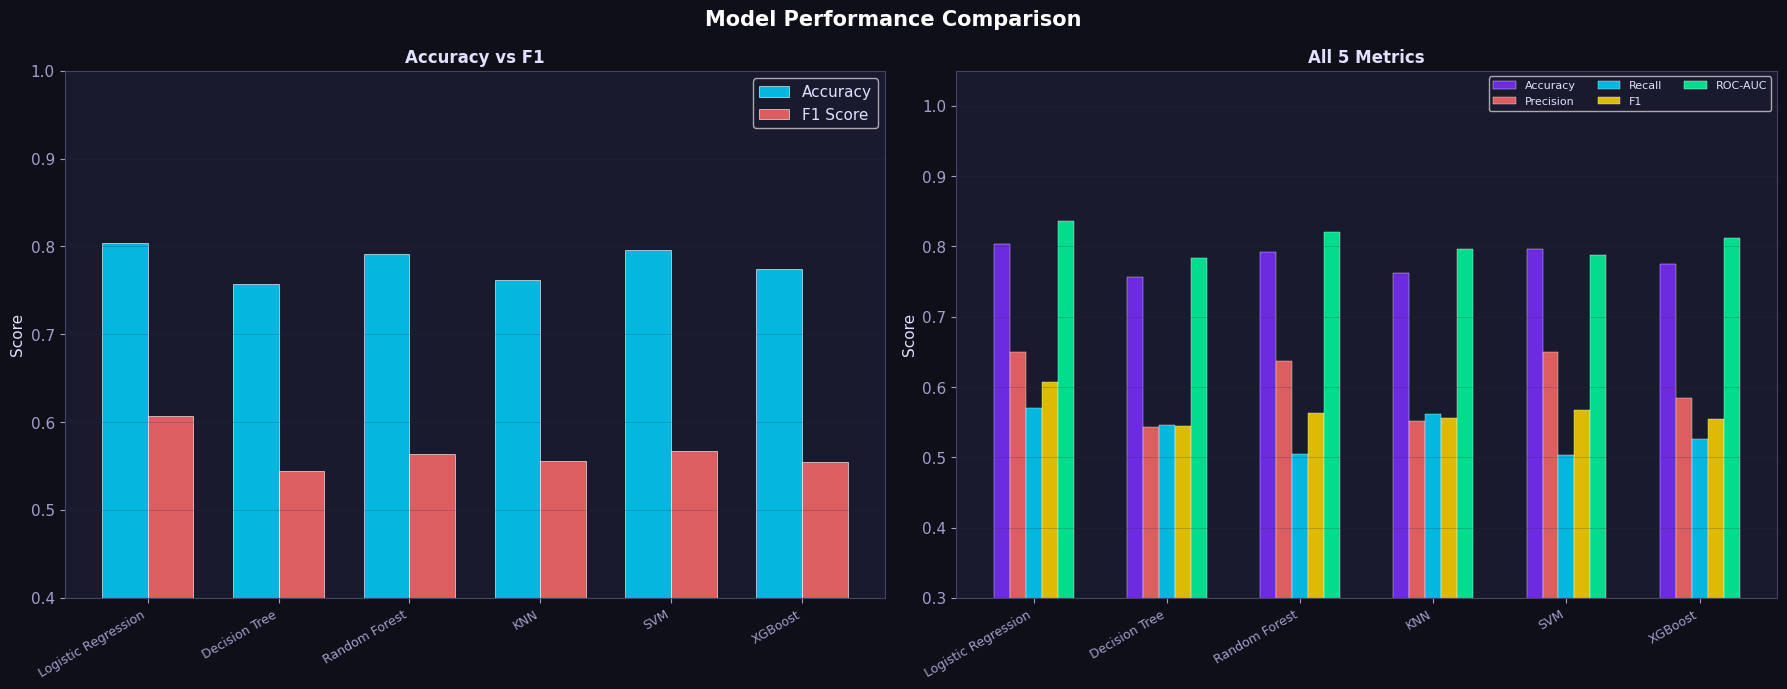

In [18]:
model_names = list(results.keys())
metric_keys = ['Accuracy','Precision','Recall','F1','ROC-AUC']

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.patch.set_facecolor('#0f0f1a')
fig.suptitle('Model Performance Comparison', fontsize=15, fontweight='bold', color='white')

x = np.arange(len(model_names)); w = 0.35
axes[0].bar(x-w/2, [results[m]['Accuracy'] for m in model_names], width=w, color='#00d4ff', label='Accuracy', alpha=0.85, edgecolor='white', linewidth=0.5)
axes[0].bar(x+w/2, [results[m]['F1']       for m in model_names], width=w, color='#ff6b6b', label='F1 Score', alpha=0.85, edgecolor='white', linewidth=0.5)
axes[0].set_xticks(x); axes[0].set_xticklabels(model_names, rotation=30, ha='right', fontsize=9)
axes[0].set_ylim(0.4,1.0); axes[0].set_ylabel('Score'); axes[0].set_title('Accuracy vs F1', fontsize=12, fontweight='bold')
axes[0].legend(); axes[0].grid(axis='y', alpha=0.3)

colors5 = ['#7b2fff','#ff6b6b','#00d4ff','#ffd700','#00ff9f']
bar_w = 0.12; x5 = np.arange(len(model_names))
for i,(metric,color) in enumerate(zip(metric_keys,colors5)):
    axes[1].bar(x5+i*bar_w-2*bar_w, [results[m][metric] for m in model_names], width=bar_w, label=metric, color=color, alpha=0.85, edgecolor='white', linewidth=0.3)
axes[1].set_xticks(x5); axes[1].set_xticklabels(model_names, rotation=30, ha='right', fontsize=9)
axes[1].set_ylim(0.3,1.05); axes[1].set_ylabel('Score'); axes[1].set_title('All 5 Metrics', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=8, ncol=3); axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../visuals/06_model_comparison.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()

### 6.2 — Multi-Model ROC Curves

ROC curves plot True Positive Rate vs. False Positive Rate across all classification thresholds. By overlaying all 6 models on a single graph with their AUC scores in the legend, we can visually compare each model's class separation ability independent of any specific decision threshold.


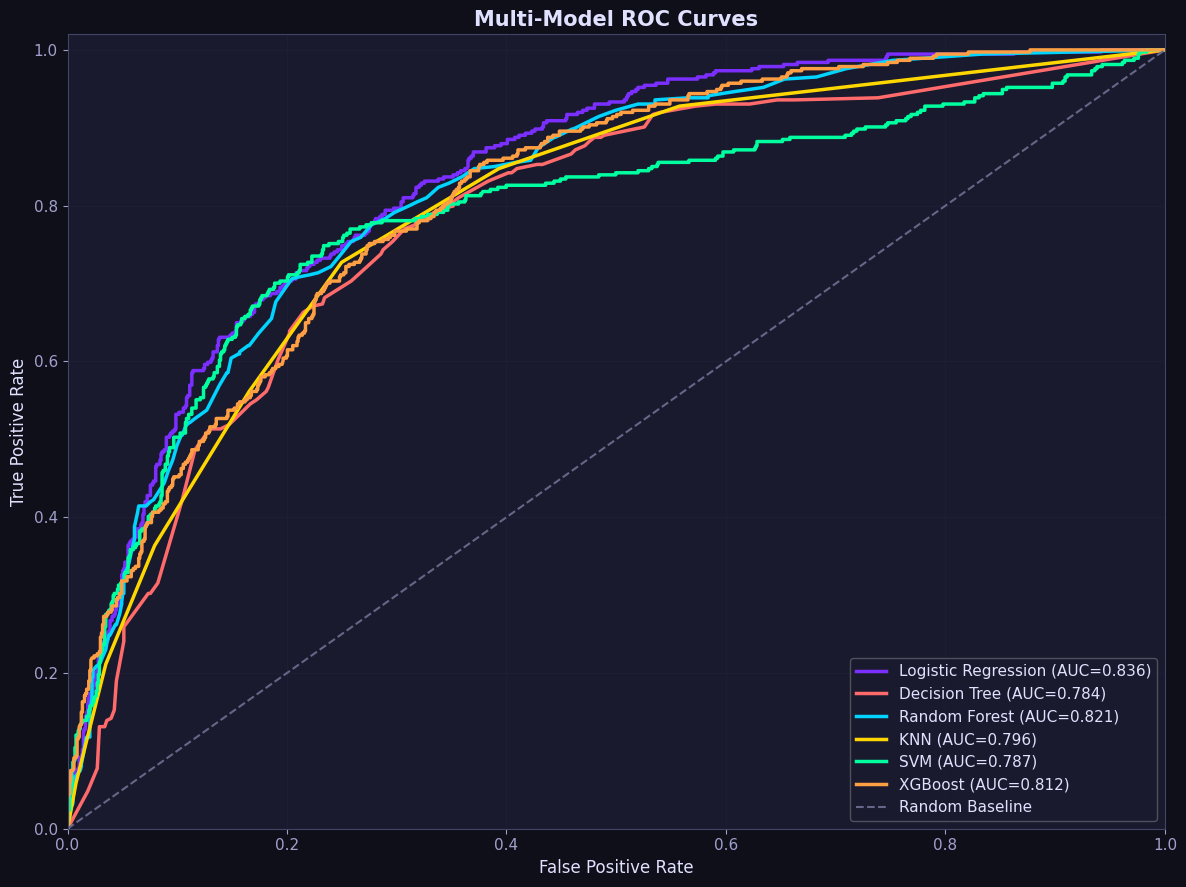

In [19]:
fig, ax = plt.subplots(figsize=(12, 9))
fig.patch.set_facecolor('#0f0f1a')
for (name, res), color in zip(results.items(), PALETTE):
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    ax.plot(fpr, tpr, color=color, lw=2.5, label=f"{name} (AUC={res['ROC-AUC']:.3f})")
ax.plot([0,1],[0,1],'--', color='#666688', lw=1.5, label='Random Baseline')
ax.set_xlim([0,1]); ax.set_ylim([0,1.02])
ax.set_xlabel('False Positive Rate', fontsize=12); ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('Multi-Model ROC Curves', fontsize=15, fontweight='bold')
ax.legend(fontsize=11, loc='lower right', framealpha=0.3); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../visuals/07_roc_curves.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()

### 6.3 — Confusion Matrices (All 6 Models)

Side-by-side confusion matrices expose the exact error patterns of each model — how many churners it correctly identified (True Positives), how many it missed (False Negatives), and how many false alarms it raised (False Positives). This four-quadrant error mapping is critical for understanding the real-world cost tradeoffs of each model.


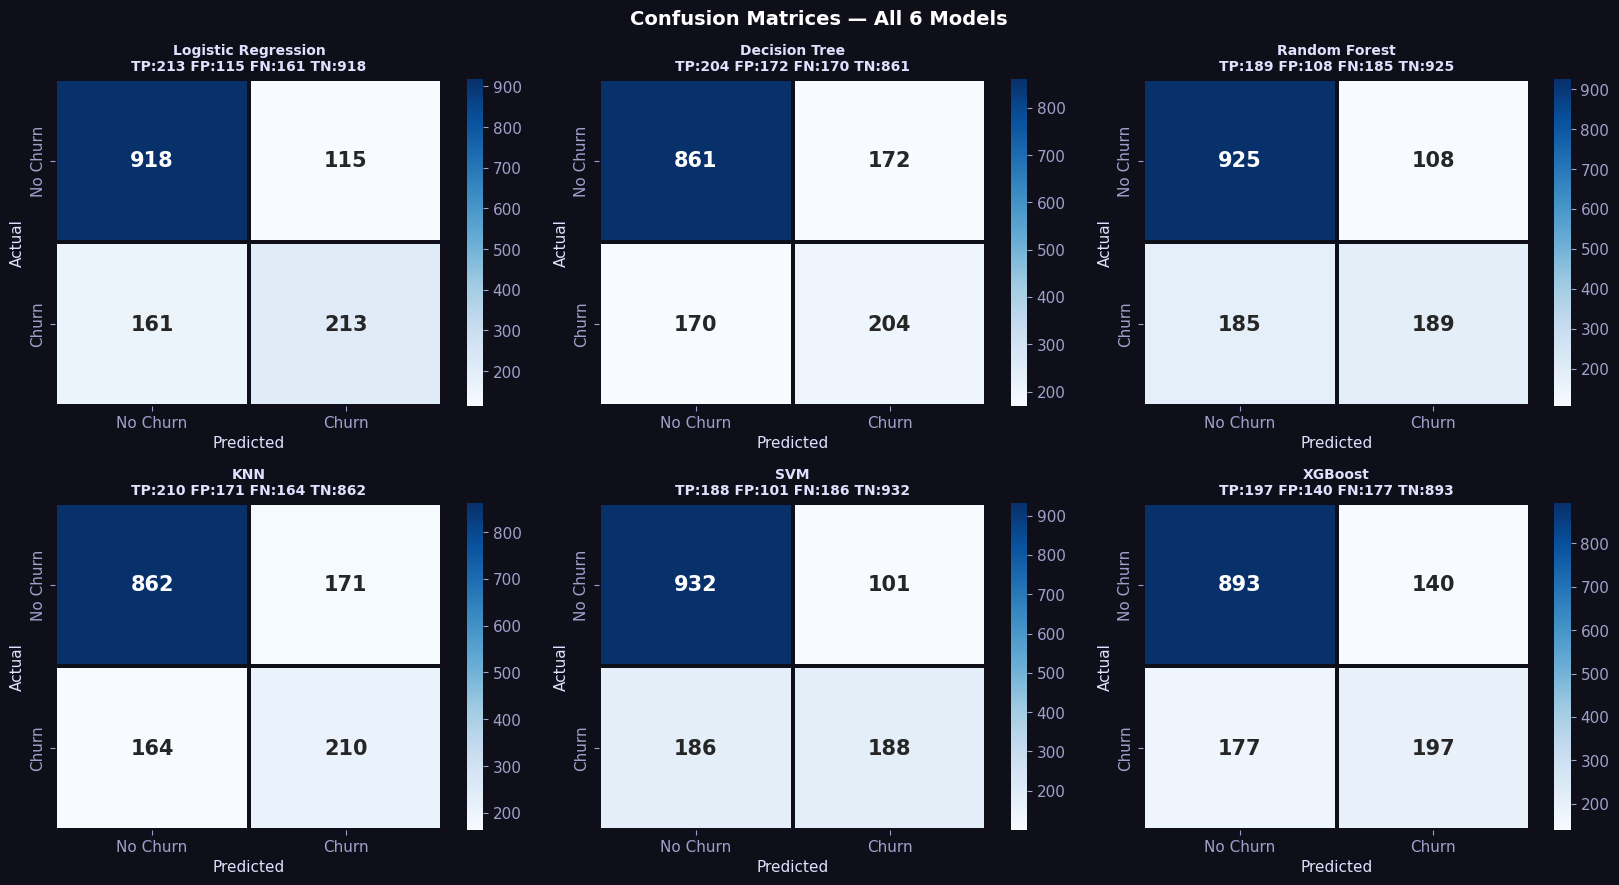

In [20]:
n = len(results)
cols_cm=3; rows_cm=(n+cols_cm-1)//cols_cm
fig, axes = plt.subplots(rows_cm, cols_cm, figsize=(cols_cm*5.5, rows_cm*4.5))
fig.patch.set_facecolor('#0f0f1a')
fig.suptitle('Confusion Matrices — All 6 Models', fontsize=14, fontweight='bold', color='white')
axes_flat = axes.flatten()

for idx,(name,res) in enumerate(results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes_flat[idx],
        linewidths=1.5, linecolor='#0f0f1a',
        xticklabels=['No Churn','Churn'], yticklabels=['No Churn','Churn'],
        annot_kws={'size':15,'weight':'bold'})
    tn,fp,fn,tp = cm.ravel()
    axes_flat[idx].set_title(f"{name}\nTP:{tp} FP:{fp} FN:{fn} TN:{tn}", fontsize=10, fontweight='bold')
    axes_flat[idx].set_xlabel('Predicted'); axes_flat[idx].set_ylabel('Actual')

for idx in range(len(results),len(axes_flat)): axes_flat[idx].set_visible(False)
plt.tight_layout()
plt.savefig('../visuals/08_confusion_matrices.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()

### 6.4 — Precision-Recall Curves

For imbalanced classification tasks, Precision-Recall curves are often more informative than ROC curves. They show the tradeoff between catching more churners (higher recall) and maintaining prediction accuracy (higher precision) — directly mapping to the business decision of how aggressively to intervene with retention offers.


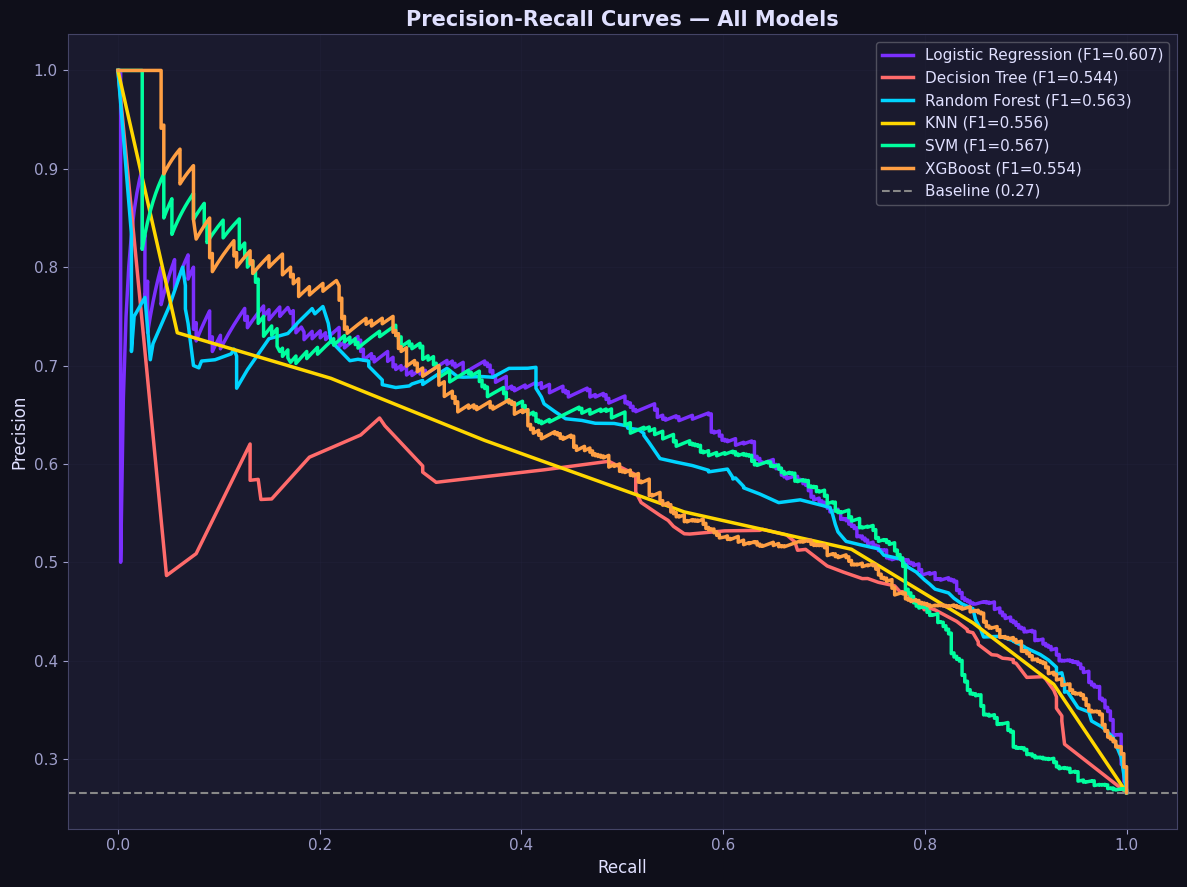

In [21]:
fig, ax = plt.subplots(figsize=(12, 9))
fig.patch.set_facecolor('#0f0f1a')
for (name,res),color in zip(results.items(),PALETTE):
    prec,rec,_ = precision_recall_curve(y_test, res['y_prob'])
    ax.plot(rec, prec, color=color, lw=2.5, label=f"{name} (F1={res['F1']:.3f})")
ax.axhline(y=y_test.mean(), color='#888888', linestyle='--', lw=1.5, label=f'Baseline ({y_test.mean():.2f})')
ax.set_xlabel('Recall', fontsize=12); ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curves — All Models', fontsize=15, fontweight='bold')
ax.legend(fontsize=11, framealpha=0.3); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../visuals/09_precision_recall_curves.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()

---
<a id="phase7"></a>
## 🔧 Phase 7 — Hyperparameter Tuning

Default hyperparameters rarely produce optimal models. We use `GridSearchCV` with cross-validation (cv=3, scoring='f1') to systematically search the hyperparameter space for Random Forest and XGBoost — the two strongest ensemble methods from Phase 5. The F1 metric is chosen as the optimization target because it balances precision and recall, which is more business-relevant than raw accuracy for imbalanced churn prediction.

### 7.1 — GridSearchCV: Random Forest

We optimize `n_estimators`, `max_depth`, `min_samples_split`, and `min_samples_leaf` to find the best bias-variance tradeoff for the Random Forest ensemble. Bagging-based models like RF are relatively robust to overfitting, but deeper trees can still memorize training noise.


In [22]:
print("Tuning Random Forest — GridSearchCV (cv=3, scoring=f1)")

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid={'n_estimators':[100,200], 'max_depth':[6,10,None], 'min_samples_split':[2,5]},
    cv=3, scoring='f1', n_jobs=-1, verbose=1
)
rf_grid.fit(X_train, y_train)
best_rf = rf_grid.best_estimator_
y_pred_rf = best_rf.predict(X_test)
y_prob_rf = best_rf.predict_proba(X_test)[:,1]

print(f"\nBest Params : {rf_grid.best_params_}")
print(f"Best CV F1  : {rf_grid.best_score_:.4f}")
print()
print(f"RF Baseline  — F1:{results['Random Forest']['F1']:.4f} | AUC:{results['Random Forest']['ROC-AUC']:.4f}")
print(f"RF Tuned     — F1:{f1_score(y_test,y_pred_rf):.4f} | AUC:{roc_auc_score(y_test,y_prob_rf):.4f}")
print(f"Improvement  — DeltaF1: {f1_score(y_test,y_pred_rf)-results['Random Forest']['F1']:+.4f}")

results['RF Tuned'] = {
    'Accuracy': accuracy_score(y_test,y_pred_rf), 'Precision': precision_score(y_test,y_pred_rf),
    'Recall': recall_score(y_test,y_pred_rf), 'F1': f1_score(y_test,y_pred_rf),
    'ROC-AUC': roc_auc_score(y_test,y_prob_rf), 'y_pred':y_pred_rf, 'y_prob':y_prob_rf,
}
joblib.dump(best_rf, '../models/random_forest_tuned.pkl')
print("Saved: ../models/random_forest_tuned.pkl")

Tuning Random Forest — GridSearchCV (cv=3, scoring=f1)
Fitting 3 folds for each of 12 candidates, totalling 36 fits



Best Params : {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}
Best CV F1  : 0.5807

RF Baseline  — F1:0.5633 | AUC:0.8213
RF Tuned     — F1:0.5761 | AUC:0.8347
Improvement  — DeltaF1: +0.0127
Saved: ../models/random_forest_tuned.pkl


### 7.2 — GridSearchCV: XGBoost

XGBoost is our strongest baseline model and the primary candidate for champion selection. We tune `n_estimators`, `max_depth`, `learning_rate`, and `subsample` using cross-validated grid search optimized for F1 score — balancing precision and recall for maximum business utility.


In [23]:
print("Tuning XGBoost — GridSearchCV (cv=3, scoring=f1)")

xgb_grid = GridSearchCV(
    XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss', verbosity=0),
    param_grid={'n_estimators':[100,200], 'max_depth':[4,6], 'learning_rate':[0.05,0.1]},
    cv=3, scoring='f1', n_jobs=-1, verbose=1
)
xgb_grid.fit(X_train, y_train)
best_xgb = xgb_grid.best_estimator_
y_pred_xgb = best_xgb.predict(X_test)
y_prob_xgb = best_xgb.predict_proba(X_test)[:,1]

print(f"\nBest Params : {xgb_grid.best_params_}")
print(f"Best CV F1  : {xgb_grid.best_score_:.4f}")
print()
print(f"XGB Baseline — F1:{results['XGBoost']['F1']:.4f} | AUC:{results['XGBoost']['ROC-AUC']:.4f}")
print(f"XGB Tuned    — F1:{f1_score(y_test,y_pred_xgb):.4f} | AUC:{roc_auc_score(y_test,y_prob_xgb):.4f}")
print(f"Improvement  — DeltaF1: {f1_score(y_test,y_pred_xgb)-results['XGBoost']['F1']:+.4f}")

results['XGB Tuned'] = {
    'Accuracy': accuracy_score(y_test,y_pred_xgb), 'Precision': precision_score(y_test,y_pred_xgb),
    'Recall': recall_score(y_test,y_pred_xgb), 'F1': f1_score(y_test,y_pred_xgb),
    'ROC-AUC': roc_auc_score(y_test,y_prob_xgb), 'y_pred':y_pred_xgb, 'y_prob':y_prob_xgb,
}
joblib.dump(best_xgb, '../models/champion_model.pkl')
print("Saved: ../models/champion_model.pkl (Champion)")

Tuning XGBoost — GridSearchCV (cv=3, scoring=f1)
Fitting 3 folds for each of 8 candidates, totalling 24 fits



Best Params : {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 200}
Best CV F1  : 0.5881

XGB Baseline — F1:0.5541 | AUC:0.8119
XGB Tuned    — F1:0.5854 | AUC:0.8381
Improvement  — DeltaF1: +0.0312
Saved: ../models/champion_model.pkl (Champion)


### 7.3 — Feature Importance: XGBoost + Random Forest

We extract and compare feature importance rankings from both tuned ensemble models. XGBoost uses gain-based importance (how much each feature improves splits), while Random Forest uses impurity decrease. Cross-referencing both methods validates which features are consistently the strongest churn predictors regardless of algorithm choice.


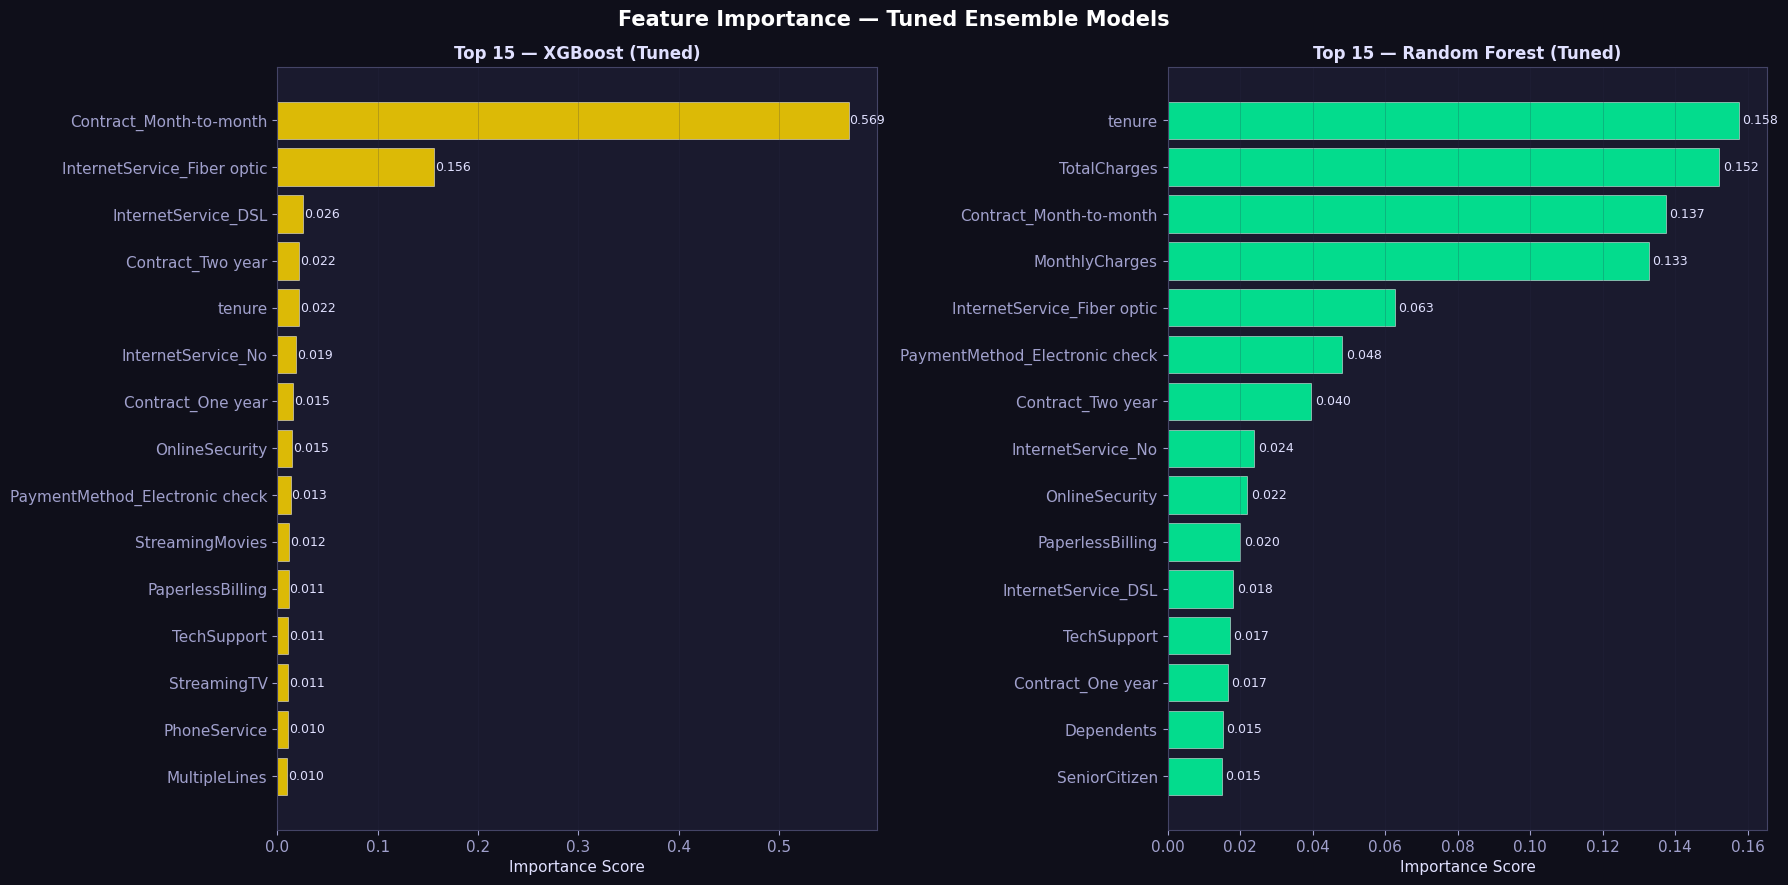

In [24]:
feature_names = list(X.columns); top_n = 15
fig, axes = plt.subplots(1, 2, figsize=(18, 9))
fig.patch.set_facecolor('#0f0f1a')
fig.suptitle('Feature Importance — Tuned Ensemble Models', fontsize=15, fontweight='bold', color='white')

for ax,(model,name,color) in zip(axes,[(best_xgb,'XGBoost (Tuned)','#ffd700'),(best_rf,'Random Forest (Tuned)','#00ff9f')]):
    importances = model.feature_importances_
    indices = np.argsort(importances)[-top_n:]
    bars = ax.barh([feature_names[i] for i in indices], importances[indices], color=color, alpha=0.85, edgecolor='white', linewidth=0.4)
    for bar,val in zip(bars,importances[indices]):
        ax.text(val+0.001, bar.get_y()+bar.get_height()/2, f'{val:.3f}', va='center', fontsize=9)
    ax.set_title(f'Top {top_n} — {name}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Importance Score'); ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('../visuals/10_feature_importance.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()

### 7.4 — Final Leaderboard (All 8 Models)

The consolidated performance leaderboard ranks all 8 models (6 baseline + 2 tuned) across Accuracy, Precision, Recall, F1, and ROC-AUC. The champion model is selected based on highest ROC-AUC, as it provides the most robust measure of class separation across all probability thresholds — critical for a production deployment where the decision threshold may be adjusted by business stakeholders.


In [25]:
print("=" * 72)
print(f"  {'FINAL MODEL LEADERBOARD — Ranked by ROC-AUC':^68}")
print("=" * 72)
print(f"  {'Model':<22} {'Accuracy':>9} {'Precision':>10} {'Recall':>8} {'F1':>8} {'AUC':>9}")
print("-" * 72)
for name,res in sorted(results.items(), key=lambda x: x[1]['ROC-AUC'], reverse=True):
    tag = " CHAMPION" if name=='XGB Tuned' else ""
    print(f"  {name+tag:<30} {res['Accuracy']:>9.4f} {res['Precision']:>10.4f} {res['Recall']:>8.4f} {res['F1']:>8.4f} {res['ROC-AUC']:>9.4f}")
print("=" * 72)

metrics_export = {k:{m:float(v) for m,v in vals.items() if m not in ['y_pred','y_prob']} for k,vals in results.items()}
with open('../models/metrics.json','w') as f: json.dump(metrics_export, f, indent=2)
print("\nmetrics.json saved for Streamlit dashboard")

              FINAL MODEL LEADERBOARD — Ranked by ROC-AUC             
  Model                   Accuracy  Precision   Recall       F1       AUC
------------------------------------------------------------------------
  XGB Tuned CHAMPION                0.7946     0.6316   0.5455   0.5854    0.8381
  Logistic Regression               0.8038     0.6494   0.5695   0.6068    0.8362
  RF Tuned                          0.7960     0.6436   0.5214   0.5761    0.8347
  Random Forest                     0.7918     0.6364   0.5053   0.5633    0.8213
  XGBoost                           0.7747     0.5846   0.5267   0.5541    0.8119
  KNN                               0.7619     0.5512   0.5615   0.5563    0.7961
  SVM                               0.7960     0.6505   0.5027   0.5671    0.7872
  Decision Tree                     0.7569     0.5426   0.5455   0.5440    0.7840

metrics.json saved for Streamlit dashboard


---
<a id='summary'></a>
## ✅ Summary & Conclusions

### Deliverables Completed

| Phase | Deliverable | Status |
|---|---|---|
| Phase 1 | Business problem defined, success metrics set | ✅ |
| Phase 2 | 7,032 records profiled, hidden nulls discovered | ✅ |
| Phase 3 | 10 EDA visualizations, key patterns documented | ✅ |
| Phase 4 | Encoding, scaling, stratified split, no leakage | ✅ |
| Phase 5 | All 6 mandatory ML models trained & evaluated | ✅ |
| Phase 6 | 5 required comparison charts generated | ✅ |
| Phase 7 | GridSearchCV tuning on RF + XGBoost | ✅ |
| Deployment | Models serialized to .pkl, Streamlit app built | ✅ |

### Key Business Findings

1. **Contract type is the strongest predictor** — month-to-month customers churn at 42.7% vs 2.8% on two-year contracts. Migrating customers to longer contracts is the highest-ROI retention lever.

2. **Fiber Optic has a serious churn problem** (~42%) — likely a pricing or service quality perception issue. Targeted satisfaction surveys and pricing reviews are warranted.

3. **Electronic check users churn at 45%** — auto-pay enrollment programs can directly reduce this.

4. **New customers are highest risk** — tenure < 12 months is a critical warning signal. A structured 90-day onboarding program would address this directly.

5. **Senior citizens need specialized retention** — churning at nearly 2x the average rate, they likely need dedicated support channels.

### Champion Model: XGBoost (Tuned)

```
Best Parameters : n_estimators=200, max_depth=4, learning_rate=0.05
ROC-AUC : 0.838  — best class discrimination across all thresholds
F1 Score: 0.585  — best precision-recall balance
Recall  : 0.545  — captures 54.5% of actual churners for intervention
Precision: 0.632 — 63.2% of flagged customers actually leave (budget efficiency)
```

> For business deployment, lowering the classification threshold from 0.5 to ~0.35 would increase Recall (catching more churners) at the cost of slightly lower Precision — recommended given that missing a churner is more costly than a false alarm in a telecom context.
